# COMP-342-L | Digital Image Processing
## Final End Semester Lab Examination — 2026
**Student Name:** Izaz Khan

**Registration No.:** B23F0001AI029

**Instructor:** Sana Saleem

In [1]:
# ─── Install & Import All Required Libraries ───
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
##  Image Upload Section
Run the cell below to upload your image(s). Upload once — the same image will be reused across all tasks.

In [4]:
# ─── Upload Your Image ───
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]
print(f'Uploaded: {image_filename}')

# Load image in BGR (OpenCV default)
img_bgr = cv2.imread(image_filename)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
print(f'Image shape: {img_bgr.shape}')

Saving 2.jpg to 2.jpg
Uploaded: 2.jpg
Image shape: (317, 159, 3)


---
## Q7 — Image Loading and Color Space Conversion

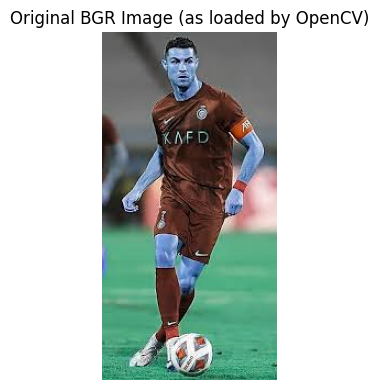

In [5]:
# ── Q7(a): Display original BGR image using Matplotlib [0.5 Mark] ──
plt.figure(figsize=(5, 4))
plt.imshow(img_bgr)  # Intentionally BGR — shows color distortion
plt.title('Original BGR Image (as loaded by OpenCV)')
plt.axis('off')
plt.tight_layout()
plt.show()

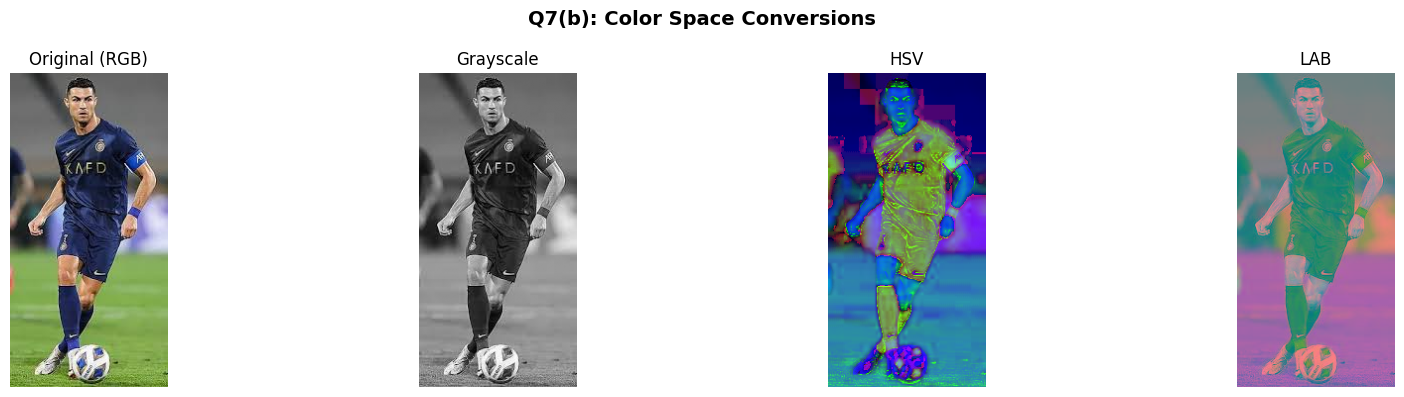

In [6]:
# ── Q7(b): Convert to Grayscale, HSV, LAB — Display all 4 [1 Mark] ──

# cv2.cvtColor() is needed because OpenCV loads images in BGR order,
# but Matplotlib expects RGB; without conversion, red and blue channels are swapped.

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_rgb);       axes[0].set_title('Original (RGB)');  axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray'); axes[1].set_title('Grayscale'); axes[1].axis('off')
axes[2].imshow(img_hsv);       axes[2].set_title('HSV');              axes[2].axis('off')
axes[3].imshow(img_lab);       axes[3].set_title('LAB');              axes[3].axis('off')
plt.suptitle('Q7(b): Color Space Conversions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q8 — Gray-Level Intensity Transformations

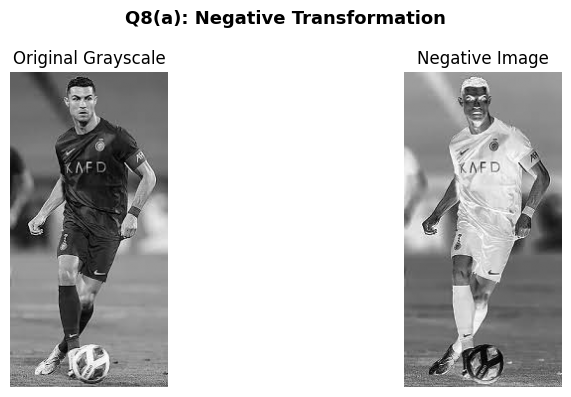

In [7]:
# ── Q8(a): Negative Transformation [0.5 Mark] ──
img_negative = 255 - img_gray

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap='gray');     axes[0].set_title('Original Grayscale'); axes[0].axis('off')
axes[1].imshow(img_negative, cmap='gray'); axes[1].set_title('Negative Image');     axes[1].axis('off')
plt.suptitle('Q8(a): Negative Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

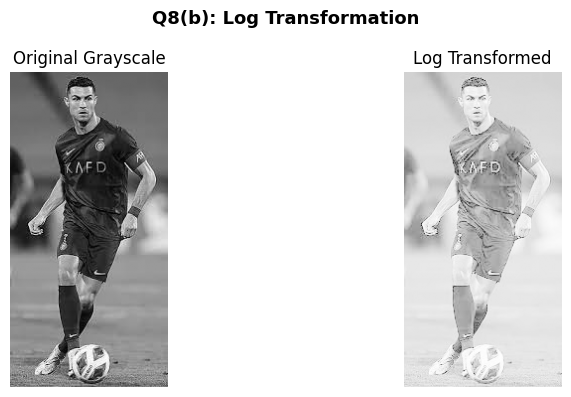

In [8]:
# ── Q8(b): Log Transformation [0.5 Mark] ──
# Formula: s = c * log(1 + r),  where c = 255 / log(1 + max_pixel)

img_float = np.float32(img_gray)
c = 255 / np.log(1 + np.max(img_float))
img_log = c * np.log(1 + img_float)
img_log = np.uint8(img_log)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap='gray');  axes[0].set_title('Original Grayscale'); axes[0].axis('off')
axes[1].imshow(img_log,  cmap='gray');  axes[1].set_title('Log Transformed');    axes[1].axis('off')
plt.suptitle('Q8(b): Log Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

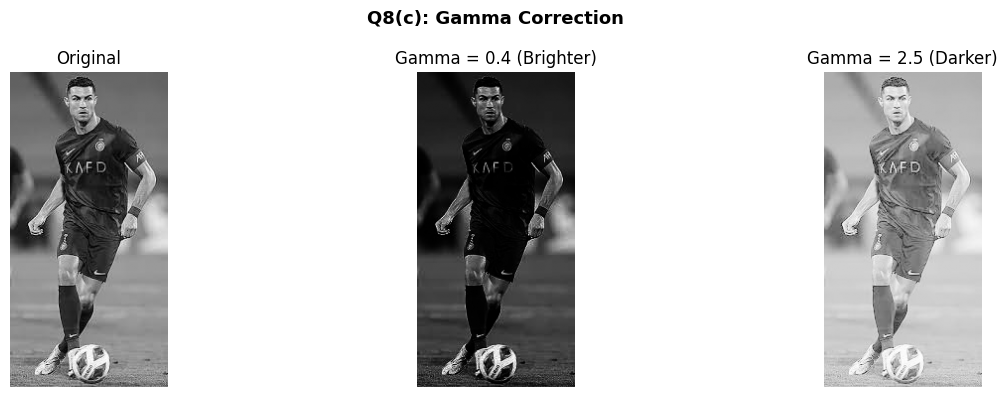

gamma=0.4: Image appears brighter — dark pixels are lifted.
gamma=2.5: Image appears darker — bright pixels are compressed.


In [9]:
# ── Q8(c): Gamma Correction — gamma=0.4 and gamma=2.5 [1 Mark] ──
# gamma < 1 brightens the image (enhances dark regions)
# gamma > 1 darkens the image (enhances bright regions)

def gamma_correction(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype='uint8')
    return cv2.LUT(image, table)

img_gamma_04 = gamma_correction(img_gray, 0.4)
img_gamma_25 = gamma_correction(img_gray, 2.5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_gray,     cmap='gray'); axes[0].set_title('Original');     axes[0].axis('off')
axes[1].imshow(img_gamma_04, cmap='gray'); axes[1].set_title('Gamma = 0.4 (Brighter)'); axes[1].axis('off')
axes[2].imshow(img_gamma_25, cmap='gray'); axes[2].set_title('Gamma = 2.5 (Darker)');   axes[2].axis('off')
plt.suptitle('Q8(c): Gamma Correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('gamma=0.4: Image appears brighter — dark pixels are lifted.')
print('gamma=2.5: Image appears darker — bright pixels are compressed.')

---
## Q9 — Histogram Analysis and Equalization

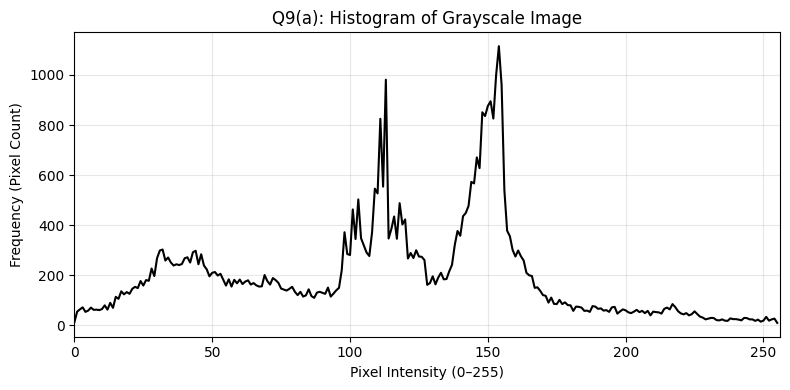

In [10]:
# ── Q9(a): Plot Histogram using cv2.calcHist() [0.5 Mark] ──
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist, color='black')
plt.title('Q9(a): Histogram of Grayscale Image')
plt.xlabel('Pixel Intensity (0–255)')
plt.ylabel('Frequency (Pixel Count)')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

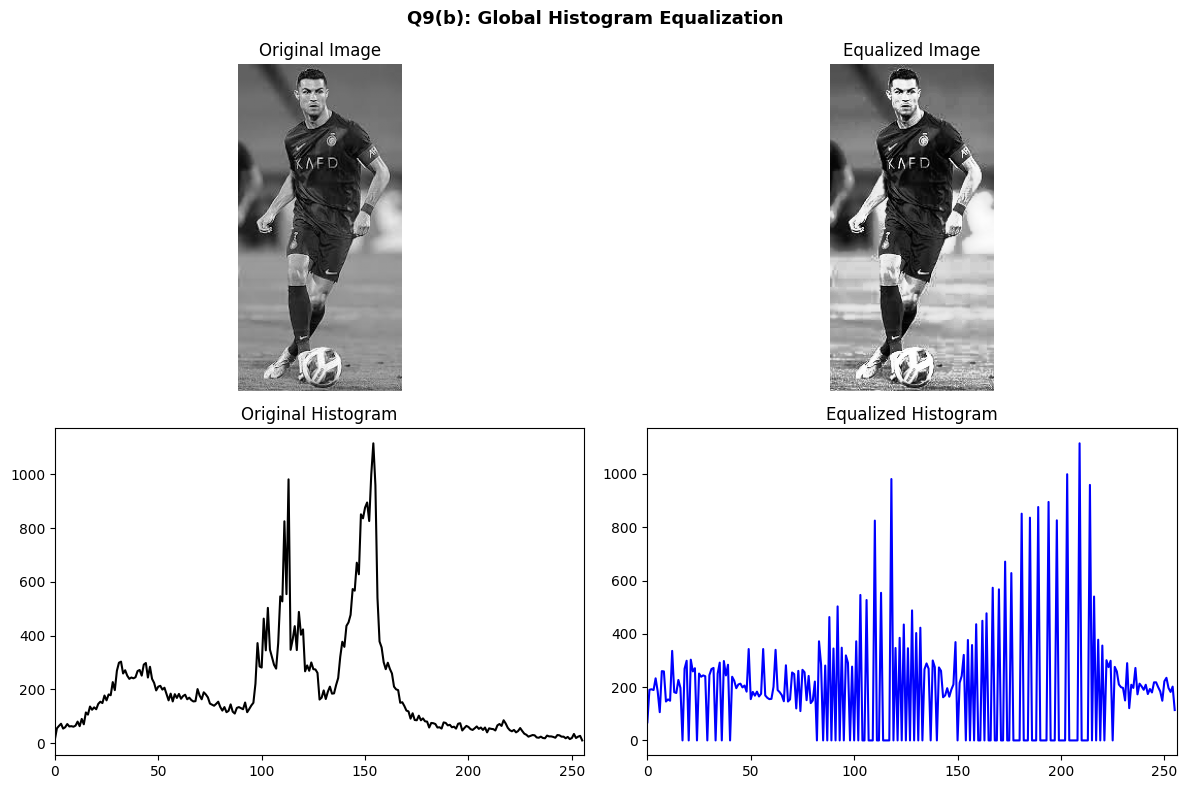

In [11]:
# ── Q9(b): Global Histogram Equalization — 2×2 subplot [1 Mark] ──
img_eq = cv2.equalizeHist(img_gray)
hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].imshow(img_gray, cmap='gray'); axes[0,0].set_title('Original Image');      axes[0,0].axis('off')
axes[0,1].imshow(img_eq,   cmap='gray'); axes[0,1].set_title('Equalized Image');     axes[0,1].axis('off')
axes[1,0].plot(hist, color='black');     axes[1,0].set_title('Original Histogram');  axes[1,0].set_xlim([0,256])
axes[1,1].plot(hist_eq, color='blue');   axes[1,1].set_title('Equalized Histogram'); axes[1,1].set_xlim([0,256])
plt.suptitle('Q9(b): Global Histogram Equalization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

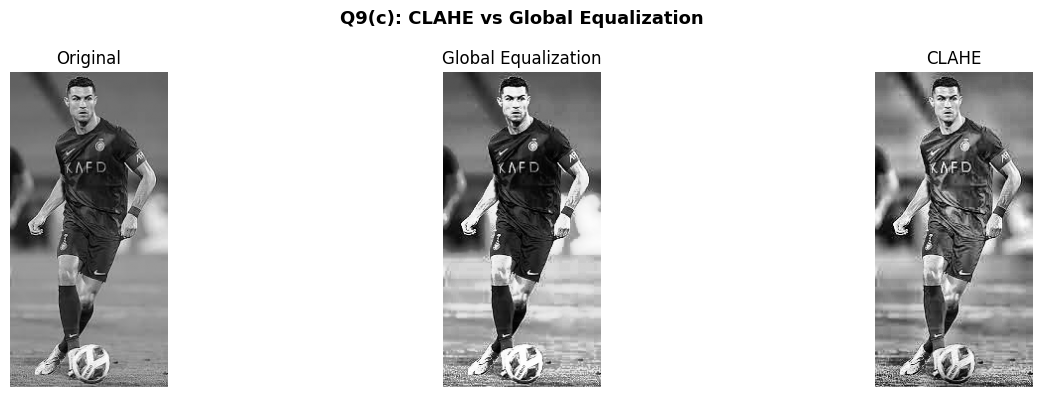

In [12]:
# ── Q9(c): CLAHE vs Global Equalization [0.5 Mark] ──
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(img_eq,    cmap='gray'); axes[1].set_title('Global Equalization'); axes[1].axis('off')
axes[2].imshow(img_clahe, cmap='gray'); axes[2].set_title('CLAHE');              axes[2].axis('off')
plt.suptitle('Q9(c): CLAHE vs Global Equalization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# CLAHE is better for images with local contrast variation because it applies
# histogram equalization on small tiles and clips contrast to avoid over-amplification.

---
## Q10 — Spatial Filtering and Noise Reduction

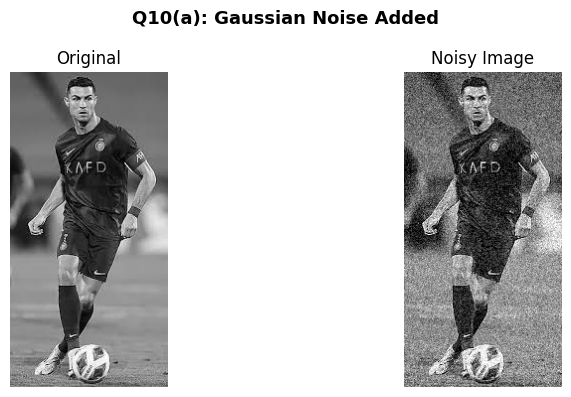

In [13]:
# ── Q10(a): Add Gaussian Noise manually using NumPy [0.5 Mark] ──
noise = np.random.normal(0, 25, img_gray.shape).astype(np.float32)
img_noisy = np.clip(img_gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original');    axes[0].axis('off')
axes[1].imshow(img_noisy, cmap='gray'); axes[1].set_title('Noisy Image'); axes[1].axis('off')
plt.suptitle('Q10(a): Gaussian Noise Added', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

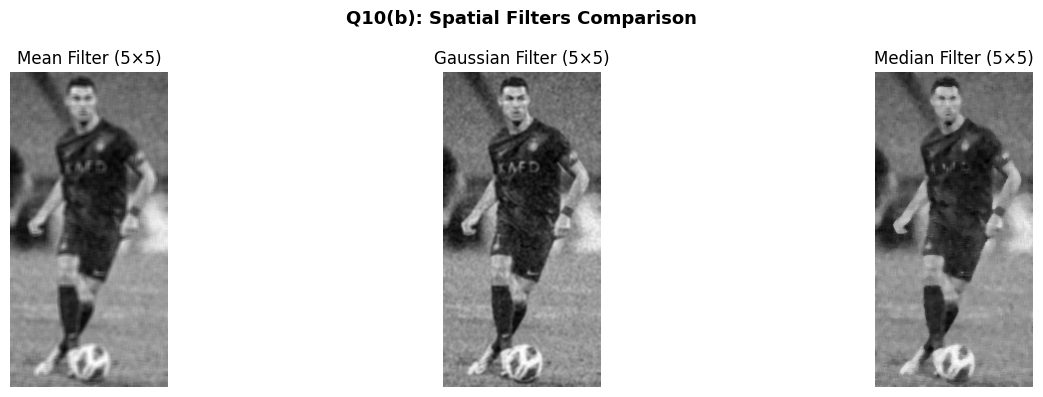

In [14]:
# ── Q10(b): Mean, Gaussian, Median Filters — 5×5 kernel [1 Mark] ──
img_mean    = cv2.blur(img_noisy, (5, 5))
img_gaussian = cv2.GaussianBlur(img_noisy, (5, 5), 0)
img_median  = cv2.medianBlur(img_noisy, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_mean,     cmap='gray'); axes[0].set_title('Mean Filter (5×5)');     axes[0].axis('off')
axes[1].imshow(img_gaussian, cmap='gray'); axes[1].set_title('Gaussian Filter (5×5)'); axes[1].axis('off')
axes[2].imshow(img_median,   cmap='gray'); axes[2].set_title('Median Filter (5×5)');   axes[2].axis('off')
plt.suptitle('Q10(b): Spatial Filters Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

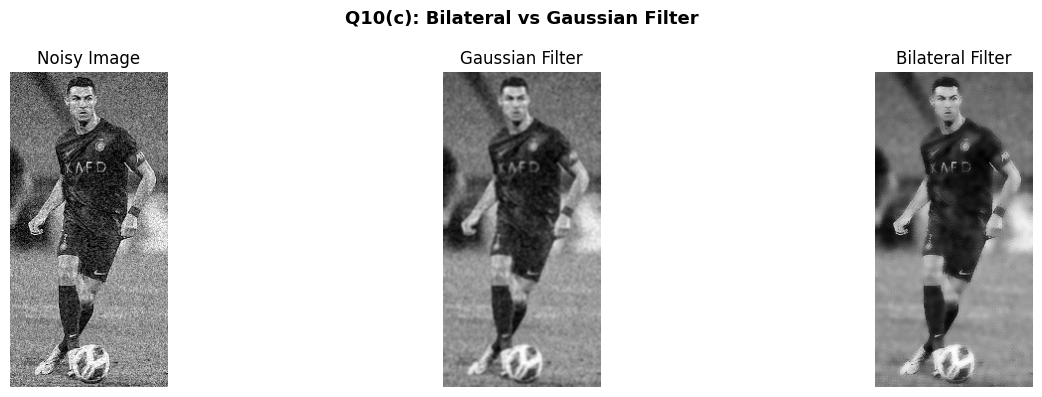

In [15]:
# ── Q10(c): Bilateral Filter — Edge Preserving [0.5 Mark] ──
# Bilateral filter preserves edges better than Gaussian because it uses
# TWO Gaussian kernels: one for spatial distance AND one for intensity difference.
# Pixels with very different intensity are given low weight — so edges stay sharp.

img_bilateral = cv2.bilateralFilter(img_noisy, d=9, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_noisy,     cmap='gray'); axes[0].set_title('Noisy Image');      axes[0].axis('off')
axes[1].imshow(img_gaussian,  cmap='gray'); axes[1].set_title('Gaussian Filter');  axes[1].axis('off')
axes[2].imshow(img_bilateral, cmap='gray'); axes[2].set_title('Bilateral Filter'); axes[2].axis('off')
plt.suptitle('Q10(c): Bilateral vs Gaussian Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q11 — Edge Detection and Morphological Operations

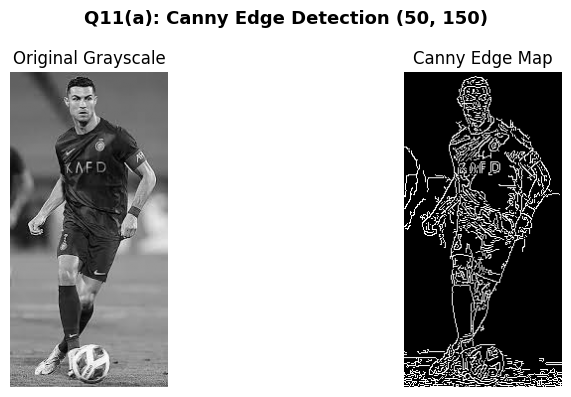

In [16]:
# ── Q11(a): Canny Edge Detection [0.5 Mark] ──
img_canny = cv2.Canny(img_gray, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray,  cmap='gray'); axes[0].set_title('Original Grayscale'); axes[0].axis('off')
axes[1].imshow(img_canny, cmap='gray'); axes[1].set_title('Canny Edge Map');     axes[1].axis('off')
plt.suptitle('Q11(a): Canny Edge Detection (50, 150)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

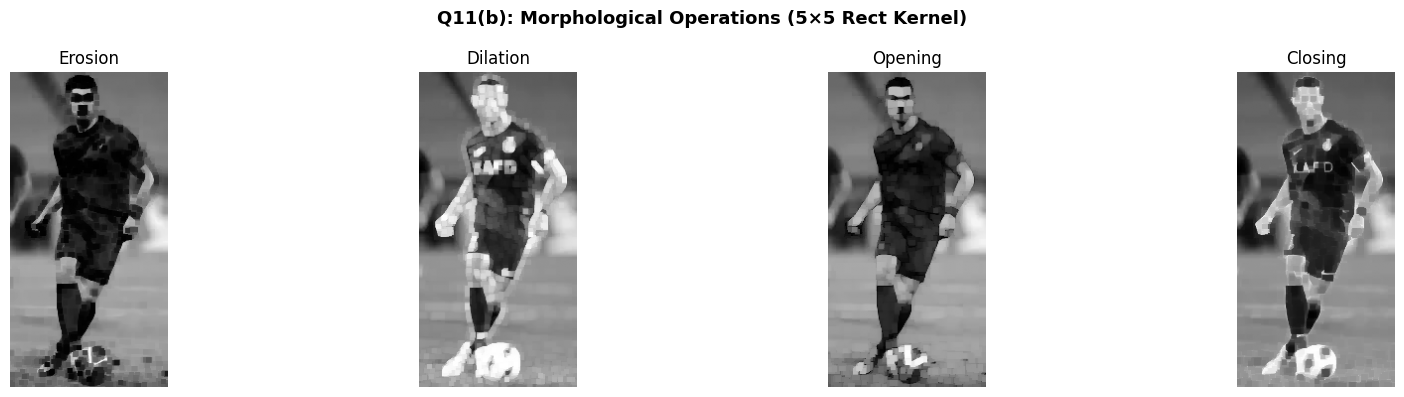

In [17]:
# ── Q11(b): Erosion, Dilation, Opening, Closing [1 Mark] ──
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

img_erode  = cv2.erode(img_gray, kernel, iterations=1)
img_dilate = cv2.dilate(img_gray, kernel, iterations=1)
img_open   = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN,  kernel)
img_close  = cv2.morphologyEx(img_gray, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_erode,  cmap='gray'); axes[0].set_title('Erosion');  axes[0].axis('off')
axes[1].imshow(img_dilate, cmap='gray'); axes[1].set_title('Dilation'); axes[1].axis('off')
axes[2].imshow(img_open,   cmap='gray'); axes[2].set_title('Opening'); axes[2].axis('off')
axes[3].imshow(img_close,  cmap='gray'); axes[3].set_title('Closing'); axes[3].axis('off')
plt.suptitle('Q11(b): Morphological Operations (5×5 Rect Kernel)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

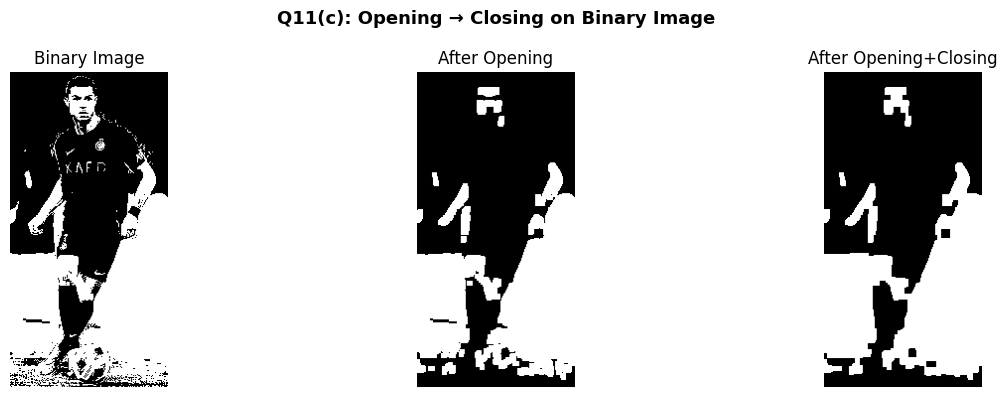

In [18]:
# ── Q11(c): Opening then Closing on Binary Image [0.5 Mark] ──
# Opening (erosion → dilation): removes small white noise specs from background.
# Closing (dilation → erosion): fills small holes/gaps inside foreground objects.
# Applying opening THEN closing: first cleans noise, then seals internal gaps —
# resulting in a smoother, cleaner binary image with solid object regions.

_, img_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
img_open_close = cv2.morphologyEx(
    cv2.morphologyEx(img_binary, cv2.MORPH_OPEN, kernel),
    cv2.MORPH_CLOSE, kernel
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_binary,     cmap='gray'); axes[0].set_title('Binary Image');       axes[0].axis('off')
axes[1].imshow(cv2.morphologyEx(img_binary, cv2.MORPH_OPEN, kernel), cmap='gray')
axes[1].set_title('After Opening'); axes[1].axis('off')
axes[2].imshow(img_open_close, cmap='gray'); axes[2].set_title('After Opening+Closing'); axes[2].axis('off')
plt.suptitle('Q11(c): Opening → Closing on Binary Image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q12 — Frequency Domain Processing

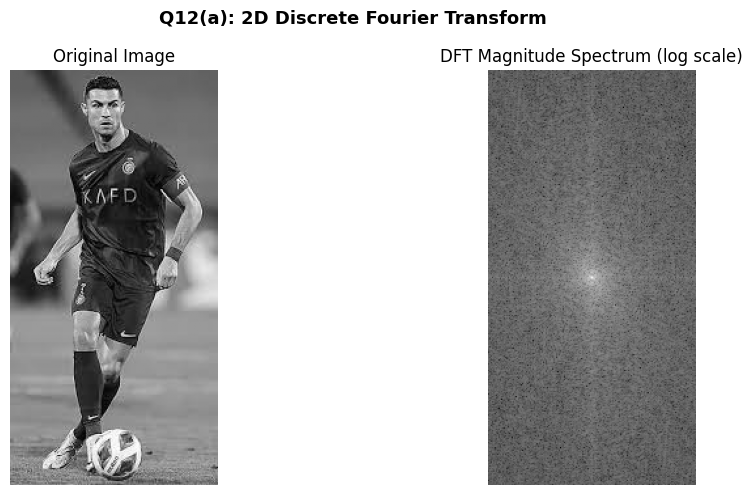

In [19]:
# ── Q12(a): 2D DFT — Magnitude Spectrum [1 Mark] ──
dft = cv2.dft(np.float32(img_gray), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)  # Shift zero-frequency component to center

magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray, cmap='gray');          axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(magnitude_spectrum, cmap='gray'); axes[1].set_title('DFT Magnitude Spectrum (log scale)'); axes[1].axis('off')
plt.suptitle('Q12(a): 2D Discrete Fourier Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

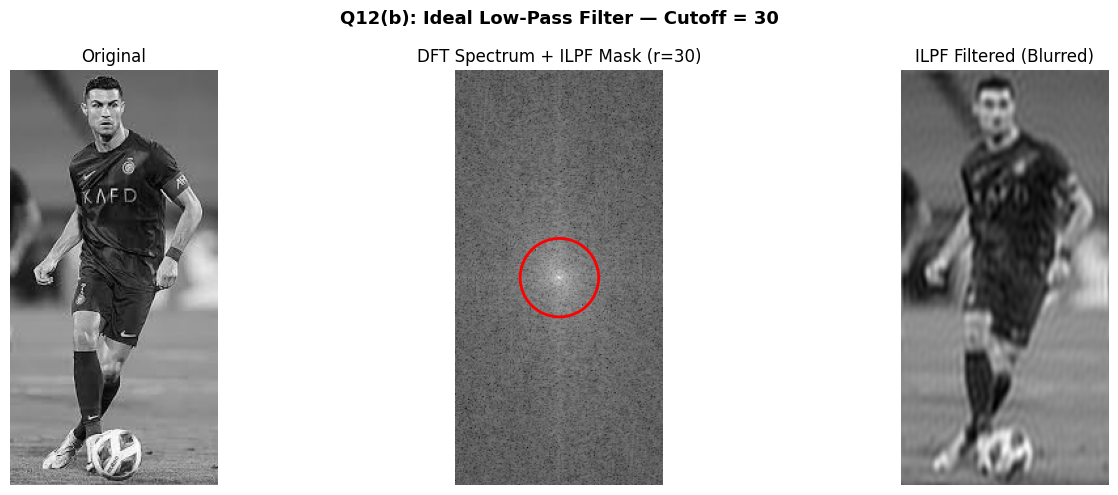

ILPF with radius=30 removes high-frequency components (edges/details),
resulting in a blurred/smoothed image with ringing artifacts at edges.


In [20]:
# ── Q12(b): Ideal Low-Pass Filter (ILPF) — Cutoff Radius = 30 [1 Mark] ──
# Visual effect: ILPF smooths/blurs the image by keeping only low frequencies.
# High-frequency details (edges, textures) are removed, resulting in a blurry image.

rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2

# Create ILPF mask
mask = np.zeros((rows, cols, 2), np.uint8)
cutoff = 30
for r in range(rows):
    for c in range(cols):
        if np.sqrt((r - crow)**2 + (c - ccol)**2) <= cutoff:
            mask[r, c] = 1

# Apply mask and compute IDFT
fshift_masked = dft_shift * mask
f_ishift = np.fft.ifftshift(fshift_masked)
img_back = cv2.idft(f_ishift)
img_filtered = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
img_filtered = np.uint8(cv2.normalize(img_filtered, None, 0, 255, cv2.NORM_MINMAX))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_gray,     cmap='gray'); axes[0].set_title('Original');            axes[0].axis('off')
axes[1].imshow(magnitude_spectrum, cmap='gray')
# Draw circle on spectrum for visualization
axes[1].add_patch(plt.Circle((ccol, crow), cutoff, color='red', fill=False, lw=2))
axes[1].set_title('DFT Spectrum + ILPF Mask (r=30)'); axes[1].axis('off')
axes[2].imshow(img_filtered, cmap='gray'); axes[2].set_title('ILPF Filtered (Blurred)'); axes[2].axis('off')
plt.suptitle('Q12(b): Ideal Low-Pass Filter — Cutoff = 30', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('ILPF with radius=30 removes high-frequency components (edges/details),')
print('resulting in a blurred/smoothed image with ringing artifacts at edges.')